# The latent country in J-space — latent-bridge v2, GPT-2 XL

How much of the residual stream lies in the J-space as Anthropic define it, where in depth is it
active, and is the J-space component that carries a latent country (*Japan* in *"Toyota is a
company from a country where the main language is"*) the same across prompts, and the same as
when the country is named? Also: how much of our difference-of-means probe directions lies in
J-space (the paper reports 10–15% for its intermediate-concept probes)?

**Answer (this run).** On the subject tokens, yes. The J-space (sparse non-negative combinations of J-lens vectors)
holds 9–17% of `‖h‖²` at K = 25 (4–15% beyond 25 random directions), with a median occupancy of
25–32 atoms by the paper's criterion in the middle and late bands, as in the paper despite
GPT-2 XL's narrower stream. At the last subject token this small component carries the latent
country about as well as the whole residual: it is closest to the same country *named* in a
neutral sentence for 71–78% of prompts among 22 countries (layers 16–40; full residual 72–84%,
logit-lens component 15–55%, random-atom component 19–34%), and for 80–83% within a language
group where the answer cannot decide (Spain vs Mexico vs Peru, Brazil vs Portugal; chance 0.39).
After the subject the J-space component carries the answer language more than the country.
Our difference-of-means probes lie mostly outside J-space: 16–25% of their norm at K = 25
(the paper: 10–15%).

## Method

**J-space** ([Verbalizable Representations Form a Global Workspace](https://transformer-circuits.pub/2026/workspace/index.html),
Methods: The J-Space). The J-lens vectors at layer l are the rows of `W_U J_l` (with the final
LayerNorm's gain and centering folded in, `v_t = J_lᵀ C(γ ⊙ u_t)`), one per vocabulary token: an
overcomplete dictionary of 50257 directions in a 1600-dimensional stream. The J-space is the set
of sparse non-negative combinations of at most K of them; the J-space component of `h` is its
nearest such point, found by gradient pursuit.

**Decomposition here.** Non-negative gradient pursuit: K greedy steps, each adding the atom
most positively correlated with the residual (atoms already chosen are excluded), followed by
three projected-gradient steps on the coefficients of the support (clamped at 0). Atoms are
unit-normalized (the paper does not state its normalization; without it the pursuit prefers
long vectors). K runs to 64 (the paper uses about 25; GPT-2 XL's stream is much narrower, so K
is chosen from the data, below).

**Controls.** (1) *K random directions*, the paper's "same-size random control set": K random
unit directions explain `K/d` of `‖h‖²` in expectation, whatever the anisotropy of `h` (1/1600
per direction). (2) *The logit-lens dictionary* (`J_l = I`), same pursuit. (3) *Best of 50257
random atoms*: the same pursuit over 50257 random unit directions, a much stricter control,
since selecting each atom out of 50257 finds a lucky direction worth about `2 ln V / d` ≈ 1.3%
of the norm.

**Metrics.**
* **Fraction of norm** `‖h_J‖² / ‖h‖²` against K, and in excess of K random directions.
* **Occupancy** (the paper's criterion): per activation, the first K at which adding a J atom
  improves the reconstruction less than adding a random direction (1/d of `‖h‖²`); the median
  over activations, then over the layers of a band. Also against the best-of-50257 control.
  Concept metrics are reported at the K of the grid {2, 4, 8, 16, 25, 32, 64} closest to the
  band's median occupancy, and for the whole grid.
* **Country atom**: is the country's token among the selected atoms; control: another country.
* **Consistency across prompts**: cosine similarity of J-space components `h_J` between prompts
  with the same country minus between prompts with different countries, counting only pairs
  from *different* subject families (Toyota vs Osaka vs sushi), so that shared templates do not
  inflate it. Same for the full residual `h`, the non-J part `h − h_J`, and the controls.
  Because prompts with the same country also share the answer language, a second comparison is
  restricted to the five countries whose language another country shares (Spain / Mexico / Peru,
  Brazil / Portugal): same country minus *different country, same language*, both over pairs of
  these countries only, isolates the country from the answer.
* **Named vs latent**: the J-space component at the country token of the 20 neutral templates of
  `concept-probe-templates.json` (*"Let me tell you about Japan."*) is averaged per country; each
  latent prompt is assigned the country whose named centroid is most similar. Top-1 accuracy
  among 22 (chance 4.5%), and *within the language group* for the same five countries (Spain vs
  Mexico vs Peru, Brazil vs Portugal; chance 0.4), where the answer language cannot decide.
* **Probes in J-space**: the fraction of each difference-of-means probe vector `w_c`
  (`latent_bridge_v2_swap.ipynb`) explained by its J-space component.

**Where.** Fixed positions, not "where the J-lens sees the country" (that selection would make
the country atom likely by construction): the last subject token, ` country`, and the last
prompt token of the 354 kept prompts, plus the named country token of the templates. All layers
of the bands of `concept_swap.ipynb` (8–16, 16–24, 24–32, 32–40, 40–47), averaged per band.
Activations are used as they are (as in the paper); a mean-centred variant (mean over prompts
per layer and position type) checks that GPT-2's large outlier dimensions do not drive the
result.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
REPO_DIR = os.path.abspath("jacobian-lens-gpt2")

# Opened from a clone (notebooks/<lens>/): use the repository root above the notebook.
local_repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "jlens" / "readout_cache.py").is_file()), None)
if local_repo is not None:
    REPO_DIR = str(local_repo)
elif os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull --ff-only
else:
    !git clone {REPO_URL} {REPO_DIR}
sys.path.append(REPO_DIR)

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display
from torch.nn.utils.rnn import pad_sequence
from tqdm.auto import tqdm
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer

import jlens
from jlens.hooks import ActivationRecorder
from jlens.strict_scoring import DecodedSpellings
from jlens.workspace import final_norm_centers

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", None)

In [3]:
MODEL_ID = "openai-community/gpt2-xl"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RUN_DIR = Path(os.environ.get("JLENS_RUN_DIR", Path(REPO_DIR) / "runs" / "gpt2-xl-convergence"))
LENS_PATH = RUN_DIR / "snapshot_lens_134.pt"
PROBE_PATH = RUN_DIR / "swap" / "probe_vectors_latent-bridge-v2.pt"  # latent_bridge_v2_swap.ipynb
OUT_DIR = RUN_DIR / "jspace"
CACHE = OUT_DIR / "latent_bridge_v2_jspace.pkl"
BANDS = ["8-16", "16-24", "24-32", "32-40", "40-47"]  # half-open block-output ranges, as in concept_swap
LAYERS = sorted({layer for band in BANDS for layer in range(*map(int, band.split("-")))})
K_MAX = 64
K_GRID = [2, 4, 8, 16, 25, 32, 64]
INNER_STEPS = 3  # projected-gradient steps on the support after each new atom
DICTIONARIES = ["J-lens", "logit lens", "random"]
VARIANTS = ["raw", "centred"]
POSITIONS = ["subject", "country token", "last", "named"]
BATCH_SIZE = 32
SEED = 0
COLORS = {"J-lens": "#2a78d6", "logit lens": "#eb6834", "random": "#52514e", "probe": "#1b9e5a",
          "full h": "#8c8c8c", "non-J part": "#c49c94"}
BAND_TICKS = [band.replace("-", "–") for band in BANDS]
D_MODEL = AutoConfig.from_pretrained(MODEL_ID).n_embd
OUT_DIR.mkdir(parents=True, exist_ok=True)


def label_ends(ax, ends, gap=0.06):
    # Write each line's name at its right end, nudged apart vertically (in place of a legend).
    lo, hi = ax.get_ylim()
    placed = []
    ends = [(min(max(y, lo), hi), text, color) for y, text, color in ends if np.isfinite(y)]
    for y, text, color in sorted(ends):
        y = max(y, placed[-1] + gap * (hi - lo)) if placed else y
        placed.append(y)
        ax.annotate(text, xy=(1.01, y), xycoords=("axes fraction", "data"), color=color, fontsize=8,
                    va="center", annotation_clip=False)


def band_axes(ax, ylabel=None):
    ax.set_xticks(range(len(BANDS)), BAND_TICKS)
    ax.set_xlabel("band of layers (block outputs)")
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25, lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)

## 1. Prompts and positions

In [4]:
pool = json.loads((Path(REPO_DIR) / "data/experiments/latent-bridge-v2-candidates.json").read_text())
v2 = json.loads((Path(REPO_DIR) / "data/experiments/latent-bridge-v2.json").read_text())
templates = json.loads((Path(REPO_DIR) / "data/experiments/concept-probe-templates.json").read_text())["templates"]
LANG = pool["languages"]
COUNTRIES = sorted(LANG)
FAMILIES = list(pool["families"])
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
kept = {(item["family"], item["subject"]) for item in v2["items"]}


def sentence(template, subject):
    text = template.format(X=subject)
    return text[0].upper() + text[1:]


rows = []
for family, spec in pool["families"].items():
    pairs = [(country, subject) for country, subjects in spec["subjects"].items() for subject in subjects]
    for i, (country, subject) in enumerate(pairs):
        if (family, subject) not in kept:
            continue
        j = (i + len(pairs) // 2) % len(pairs)
        while pairs[j][0] == country:
            j = (j + 1) % len(pairs)
        prompt = sentence(spec["template"], subject)
        ids = [tokenizer.bos_token_id, *tokenizer(prompt).input_ids]
        n_subject = len(tokenizer(prompt[:len(subject)]).input_ids)
        tail = [tokenizer.decode([t]) for t in ids[1 + n_subject:]]
        positions = {"subject": n_subject, "country token": 1 + n_subject + tail.index(" country"),
                     "last": len(ids) - 1}
        for position, index in positions.items():
            rows.append({"family": family, "subject": subject, "country": country, "control": pairs[j][0],
                         "position": position, "ids": ids, "index": index})
for country in COUNTRIES:
    token = tokenizer.encode(" " + country)
    for t, template in enumerate(templates):
        prefix = [tokenizer.bos_token_id, *tokenizer(template.split("{x}")[0].rstrip()).input_ids]
        ids = [tokenizer.bos_token_id, *tokenizer(template.format(x=country)).input_ids]
        assert ids[len(prefix):len(prefix) + len(token)] == token, (template, country)
        rows.append({"family": "named", "subject": f"template {t}", "country": country,
                     "control": COUNTRIES[(COUNTRIES.index(country) + 11) % len(COUNTRIES)],
                     "position": "named", "ids": ids, "index": len(prefix)})
sites = pd.DataFrame(rows)
assert all(len(tokenizer.encode(" " + c)) == 1 for c in COUNTRIES)
sites.groupby("position", sort=False).agg(rows=("country", "size"), countries=("country", "nunique"),
                                           families=("family", "nunique"))

,rows,countries,families
position,,,
subject,354,22,5
country token,354,22,5
last,354,22,5
named,440,22,1


## 2. Activations and J-space decompositions

One batched pass records the block outputs of every band layer at the chosen positions; then,
per layer, the pursuit runs on all rows for each dictionary and variant, and the metrics are
computed on the GPU. Only summaries are cached (`CACHE`), so a rerun loads no model.

In [5]:
@torch.no_grad()
def pursuit(H, D, k_max, inner=INNER_STEPS, snapshots=K_GRID):
    """Non-negative gradient pursuit of rows of H [P, d] over unit atoms D [V, d].

    Returns the fraction of norm explained after each step [P, k_max], the support [P, k_max], and
    per snapshot K the J-space component [P, d] and coefficients [P, K].
    """
    P = H.shape[0]
    support = torch.zeros(P, k_max, dtype=torch.long, device=H.device)
    coef = torch.zeros(P, k_max, device=H.device)
    residual = H.clone()
    norm2 = (H * H).sum(1).clamp_min(1e-12)
    fve = torch.zeros(P, k_max, device=H.device)
    components = {}
    for k in range(k_max):
        corr = residual @ D.T
        if k:
            corr.scatter_(1, support[:, :k], -torch.inf)
        support[:, k] = corr.argmax(1)
        del corr
        atoms = D[support[:, :k + 1]]  # [P, k+1, d]
        for _ in range(inner):
            grad = torch.einsum("pkd,pd->pk", atoms, residual)
            direction = torch.einsum("pk,pkd->pd", grad, atoms)
            step = (residual * direction).sum(1) / (direction * direction).sum(1).clamp_min(1e-12)
            coef[:, :k + 1] = (coef[:, :k + 1] + step[:, None] * grad).clamp_min(0)
            residual = H - torch.einsum("pk,pkd->pd", coef[:, :k + 1], atoms)
        fve[:, k] = 1 - (residual * residual).sum(1) / norm2
        if k + 1 in snapshots:
            components[k + 1] = (H - residual, coef[:, :k + 1].clone())
    return fve, support, components


def occupancy(fve_dict, control_gain):
    # Per row: atoms added before the dictionary's marginal gain first falls to the control's.
    gain = torch.diff(fve_dict, dim=1, prepend=torch.zeros_like(fve_dict[:, :1]))
    below = gain <= control_gain
    return torch.where(below.any(1), below.float().argmax(1), torch.full_like(gain[:, 0], K_MAX))


def consistency(X, country, language, family, mask):
    """Mean cosines over pairs from different families: same country and different country (all
    countries); same country and different country with the same language (shared-language
    countries only)."""
    X = F.normalize(X[mask], dim=1)
    c, lang, f, shared = country[mask], language[mask], family[mask], SHARED[country[mask]]
    cos = X @ X.T
    cross = f[:, None] != f[None, :]
    same = (c[:, None] == c[None, :]) & cross
    diff = (c[:, None] != c[None, :]) & cross
    both_shared = shared[:, None] & shared[None, :]
    same_shared = same & both_shared
    same_language = diff & both_shared & (lang[:, None] == lang[None, :])
    return (cos[same].mean().item(), cos[diff].mean().item(), cos[same_shared].mean().item(),
            cos[same_language].mean().item())


def named_accuracy(X, country, position, latent, within_language=False):
    """Assign each latent row the country whose named-template centroid is most similar; with
    within_language, only among countries of the row's language (shared-language rows only)."""
    named = position == POSITIONS.index("named")
    centroids = torch.stack([X[named & (country == c)].mean(0) for c in range(len(COUNTRIES))])
    if within_language:
        latent = latent & SHARED[country]
    sims = F.normalize(X[latent], dim=1) @ F.normalize(centroids, dim=1).T
    if within_language:
        sims = sims.masked_fill(COUNTRY_LANGUAGE[None, :] != COUNTRY_LANGUAGE[country[latent]][:, None], -torch.inf)
    return (sims.argmax(1) == country[latent]).float().mean().item()


if not CACHE.exists():
    hf_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float32).to(DEVICE).eval()
    model = jlens.from_hf(hf_model, tokenizer, compile=False, force_bos=False)
    lens = jlens.JacobianLens.load(str(LENS_PATH))
    probe = torch.load(PROBE_PATH)
    assert probe["concepts"] == COUNTRIES
    # Unembedding with ln_f's gain (and centering, for LayerNorm) folded in: rows are C(γ ⊙ u_t).
    g = hf_model.transformer.ln_f.weight.float()[None] * hf_model.get_output_embeddings().weight.float()
    if final_norm_centers(model):
        g = g - g.mean(1, keepdim=True)
    generator = torch.Generator(device=DEVICE).manual_seed(SEED)
    random_dictionary = F.normalize(torch.randn(g.shape, generator=generator, device=DEVICE), dim=1)
    logit_dictionary = F.normalize(g, dim=1)
    spellings = DecodedSpellings(tokenizer, vocab_size=g.shape[0])
    country_ids = [sorted(spellings(c, False)) for c in COUNTRIES]

    # Activations at the chosen positions, every band layer: [layer] -> [rows, d].
    H = {layer: torch.empty(len(sites), model.d_model, device=DEVICE) for layer in LAYERS}
    order = np.argsort(sites.ids.map(len).to_numpy(), kind="stable")
    with torch.no_grad():
        for start in tqdm(range(0, len(order), BATCH_SIZE), desc="activations"):
            index = order[start:start + BATCH_SIZE]
            chunk = sites.iloc[index]
            ids = pad_sequence([torch.tensor(i) for i in chunk.ids], batch_first=True,
                               padding_value=tokenizer.eos_token_id).to(DEVICE)
            with ActivationRecorder(model.layers, at=LAYERS) as recorder:
                hf_model(input_ids=ids)
            rows = torch.arange(len(index), device=DEVICE)
            positions = torch.tensor(chunk["index"].to_numpy(), device=DEVICE)
            target = torch.tensor(index, device=DEVICE)
            for layer in LAYERS:
                H[layer][target] = recorder.activations[layer][rows, positions].float()
            del recorder

    country = torch.tensor(sites.country.map(COUNTRIES.index).to_numpy(), device=DEVICE)
    LANGUAGES = sorted(set(LANG.values()))
    language = torch.tensor(sites.country.map(lambda c: LANGUAGES.index(LANG[c])).to_numpy(), device=DEVICE)
    COUNTRY_LANGUAGE = torch.tensor([LANGUAGES.index(LANG[c]) for c in COUNTRIES], device=DEVICE)
    SHARED = torch.bincount(COUNTRY_LANGUAGE, minlength=len(LANGUAGES))[COUNTRY_LANGUAGE] > 1  # [country]
    print("shared-language countries:", [c for c, s_ in zip(COUNTRIES, SHARED.tolist(), strict=True) if s_])
    control = torch.tensor(sites.control.map(COUNTRIES.index).to_numpy(), device=DEVICE)
    family = torch.tensor(sites.family.map({f: i for i, f in enumerate([*FAMILIES, "named"])}).to_numpy(),
                          device=DEVICE)
    position = torch.tensor(sites.position.map(POSITIONS.index).to_numpy(), device=DEVICE)
    is_country_atom = torch.zeros(len(COUNTRIES), g.shape[0], dtype=torch.bool, device=DEVICE)
    for c, ids_ in enumerate(country_ids):
        is_country_atom[c, ids_] = True

    curves, rows_out, probe_rows = [], [], []
    for layer in tqdm(LAYERS, desc="layers"):
        J = lens.jacobians[layer].to(DEVICE, torch.float32)
        dictionaries = {"J-lens": F.normalize(g @ J, dim=1), "logit lens": logit_dictionary,
                        "random": random_dictionary}
        for variant in VARIANTS:
            X = H[layer].clone()
            if variant == "centred":
                for p in range(len(POSITIONS)):
                    X[position == p] -= X[position == p].mean(0)
            fves, results = {}, {}
            for name, D in dictionaries.items():
                fves[name], support, components = pursuit(X, D, K_MAX)
                results[name] = (support, components)
            occ = occupancy(fves["J-lens"], 1 / D_MODEL)
            occ_best = occupancy(fves["J-lens"], torch.diff(fves["random"], dim=1,
                                                           prepend=torch.zeros_like(fves["random"][:, :1])))
            for p, pos in enumerate(POSITIONS):
                m = position == p
                for name in DICTIONARIES:
                    curve = fves[name][m].mean(0).cpu().numpy()
                    curves.append({"layer": layer, "variant": variant, "position": pos, "dictionary": name,
                                   "fve": curve})
                rows_out.append({"layer": layer, "variant": variant, "position": pos, "metric": "occupancy",
                                 "k": None, "dictionary": "J-lens", "value": occ[m].median().item()})
                rows_out.append({"layer": layer, "variant": variant, "position": pos,
                                 "metric": "occupancy vs best of 50257", "k": None, "dictionary": "J-lens",
                                 "value": occ_best[m].median().item()})
            for name in DICTIONARIES:
                support, components = results[name]
                for k, (component, _coef) in components.items():
                    selected = support[:, :k]
                    for p, pos in enumerate(POSITIONS):
                        m = position == p
                        values = {}
                        if name != "random":
                            hit = is_country_atom[country[m]].gather(1, selected[m]).any(1)
                            ctl = is_country_atom[control[m]].gather(1, selected[m]).any(1)
                            values["country atom selected"] = hit.float().mean().item()
                            values["control atom selected"] = ctl.float().mean().item()
                        if pos != "named":
                            same, diff, same_shared, same_language = consistency(component, country, language,
                                                                                 family, m)
                            values["consistency"] = same - diff
                            values["consistency vs same language"] = same_shared - same_language
                            values["cos same country"] = same
                            values["cos different country"] = diff
                            values["cos different country, same language"] = same_language
                            values["named-centroid accuracy"] = named_accuracy(component, country, position, m)
                            values["named-centroid accuracy within language"] = named_accuracy(
                                component, country, position, m, within_language=True)
                        for metric, value in values.items():
                            rows_out.append({"layer": layer, "variant": variant, "position": pos, "metric": metric,
                                             "k": k, "dictionary": name, "value": value})
                        if name == "J-lens" and pos != "named":
                            for label, vectors in (("full h", X), ("non-J part", X - component)):
                                same, diff, same_shared, same_language = consistency(vectors, country, language,
                                                                                     family, m)
                                rows_out.append({"layer": layer, "variant": variant, "position": pos,
                                                 "metric": "consistency", "k": k, "dictionary": label,
                                                 "value": same - diff})
                                rows_out.append({"layer": layer, "variant": variant, "position": pos,
                                                 "metric": "consistency vs same language", "k": k,
                                                 "dictionary": label, "value": same_shared - same_language})
                                rows_out.append({"layer": layer, "variant": variant, "position": pos,
                                                 "metric": "named-centroid accuracy within language", "k": k,
                                                 "dictionary": label, "value": named_accuracy(
                                                     vectors, country, position, m, within_language=True)})
                                rows_out.append({"layer": layer, "variant": variant, "position": pos,
                                                 "metric": "named-centroid accuracy", "k": k, "dictionary": label,
                                                 "value": named_accuracy(vectors, country, position, m)})
        # Probe vectors in J-space: fraction of each w_c explained by K atoms of each dictionary.
        W = probe["vectors"][layer].to(DEVICE, torch.float32)
        for name, D in dictionaries.items():
            fve_probe, _, _ = pursuit(W, D, K_MAX)
            probe_rows.append({"layer": layer, "dictionary": name, "fve": fve_probe.mean(0).cpu().numpy()})
        del dictionaries, J
        torch.cuda.empty_cache()
    pd.to_pickle({"curves": pd.DataFrame(curves), "metrics": pd.DataFrame(rows_out),
                  "probe": pd.DataFrame(probe_rows), "lens": str(LENS_PATH), "probe_path": str(PROBE_PATH),
                  "model": MODEL_ID, "dtype": "float32", "k_max": K_MAX, "inner_steps": INNER_STEPS,
                  "seed": SEED}, CACHE)
    model = hf_model = lens = H = None
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
cached = pd.read_pickle(CACHE)
curves, metrics, probe_fve = cached["curves"], cached["metrics"], cached["probe"]
band_of = {layer: band for band in BANDS for layer in range(*map(int, band.split("-")))}
for frame in (curves, metrics, probe_fve):
    frame["band"] = frame.layer.map(band_of)
print(f"{len(LAYERS)} layers, {len(sites)} rows, K up to {K_MAX}")

39 layers, 1502 rows, K up to 64


## 3. Where is the J-space active?

Fraction of `‖h‖²` explained by K J atoms, in excess of K random directions (`K/d`), and
occupancy. Mean over the layers of each band and the rows of each position.

In [6]:
def fve_at(frame, k):
    return frame.fve.map(lambda curve: curve[k - 1])


layer_rows = []
for (variant, pos, layer), group in curves.groupby(["variant", "position", "layer"]):
    by = group.set_index("dictionary").fve
    layer_rows.append({"variant": variant, "position": pos, "layer": layer, "band": band_of[layer],
                       "J, K=25": by["J-lens"][24], "J, K=64": by["J-lens"][63],
                       "logit lens, K=25": by["logit lens"][24], "best of 50257 random, K=25": by["random"][24]})
per_layer = pd.DataFrame(layer_rows)
occ = metrics[metrics.metric.isin(["occupancy", "occupancy vs best of 50257"])].pivot_table(
    index=["variant", "position", "layer"], columns="metric", values="value").reset_index()
per_layer = per_layer.merge(occ, on=["variant", "position", "layer"])
active = per_layer.groupby(["variant", "position", "band"]).agg(
    **{"median occupancy": ("occupancy", "median"),
       "median occupancy vs best of 50257": ("occupancy vs best of 50257", "median"),
       "J fraction of norm, K=25": ("J, K=25", "mean"), "J fraction of norm, K=64": ("J, K=64", "mean"),
       "logit fraction, K=25": ("logit lens, K=25", "mean"),
       "best of 50257 random, K=25": ("best of 50257 random, K=25", "mean")}).reset_index()
active["25 random directions"] = 25 / D_MODEL
active["J excess over random set, K=25"] = active["J fraction of norm, K=25"] - 25 / D_MODEL
active["logit excess over random set, K=25"] = active["logit fraction, K=25"] - 25 / D_MODEL
display(active.set_index(["variant", "position", "band"]).loc[VARIANTS].reindex(POSITIONS, level="position")
        .reindex(BANDS, level="band").round(3))
OCC = active.groupby(["variant", "band"])["median occupancy"].median()
K_AT = {key: min(K_GRID, key=lambda k: abs(k - value)) for key, value in OCC.items()}
print("K used per band (grid value closest to the median occupancy):",
      {f"{v}, layers {b}": k for (v, b), k in K_AT.items()})

median occupancy  median occupancy vs best of 50257  J fraction of norm, K=25  J fraction of norm, K=64  logit fraction, K=25  best of 50257 random, K=25  25 random directions  J excess over random set, K=25  \
variant position      band                                                                                                                                                                                                                     
raw     subject       8-16               25.0                                1.0                     0.094                     0.104                 0.078                       0.190                 0.016                           0.079   
                      16-24              27.0                                1.0                     0.087                     0.098                 0.075                       0.190                 0.016                           0.071   
                      24-32              29.0                                1.0                     0.091                     0.105                 0.081                       0.191                 0.016                           0.076   
                      32-40              32.0                                3.0                     0.114                     0.130                 0.105                       0.189                 0.016                           0.098   
                      40-47              29.0                                3.0                     0.109                     0.121                 0.111                       0.188                 0.016                           0.093   
        country token 8-16               21.5                                1.0                     0.059                     0.067                 0.060                       0.194                 0.016                           0.043   
                      16-24              24.0                                1.0                     0.063                     0.072                 0.069                       0.194                 0.016                           0.047   
                      24-32              26.0                                1.0                     0.083                     0.094                 0.088                       0.197                 0.016                           0.068   
                      32-40              31.0                                4.0                     0.127                     0.142                 0.125                       0.193                 0.016                           0.112   
                      40-47              30.0                                4.0                     0.127                     0.139                 0.130                       0.185                 0.016                           0.111   
        last          8-16               11.0                                0.0                     0.022                     0.027                 0.037                       0.192                 0.016                           0.007   
                      16-24              18.5                                0.0                     0.041                     0.047                 0.056                       0.201                 0.016                           0.025   
                      24-32              24.5                                1.0                     0.078                     0.089                 0.085                       0.199                 0.016                           0.063   
                      32-40              30.5                                3.5                     0.165                     0.180                 0.157                       0.196                 0.016                           0.149   
                      40-47              31.0                                4.0                     0.160                     0.173                 0.159                       0.196       

K used per band (grid value closest to the median occupancy): {'centred, layers 16-24': 32, 'centred, layers 24-32': 32, 'centred, layers 32-40': 32, 'centred, layers 40-47': 32, 'centred, layers 8-16': 25, 'raw, layers 16-24': 25, 'raw, layers 24-32': 25, 'raw, layers 32-40': 32, 'raw, layers 40-47': 32, 'raw, layers 8-16': 25}


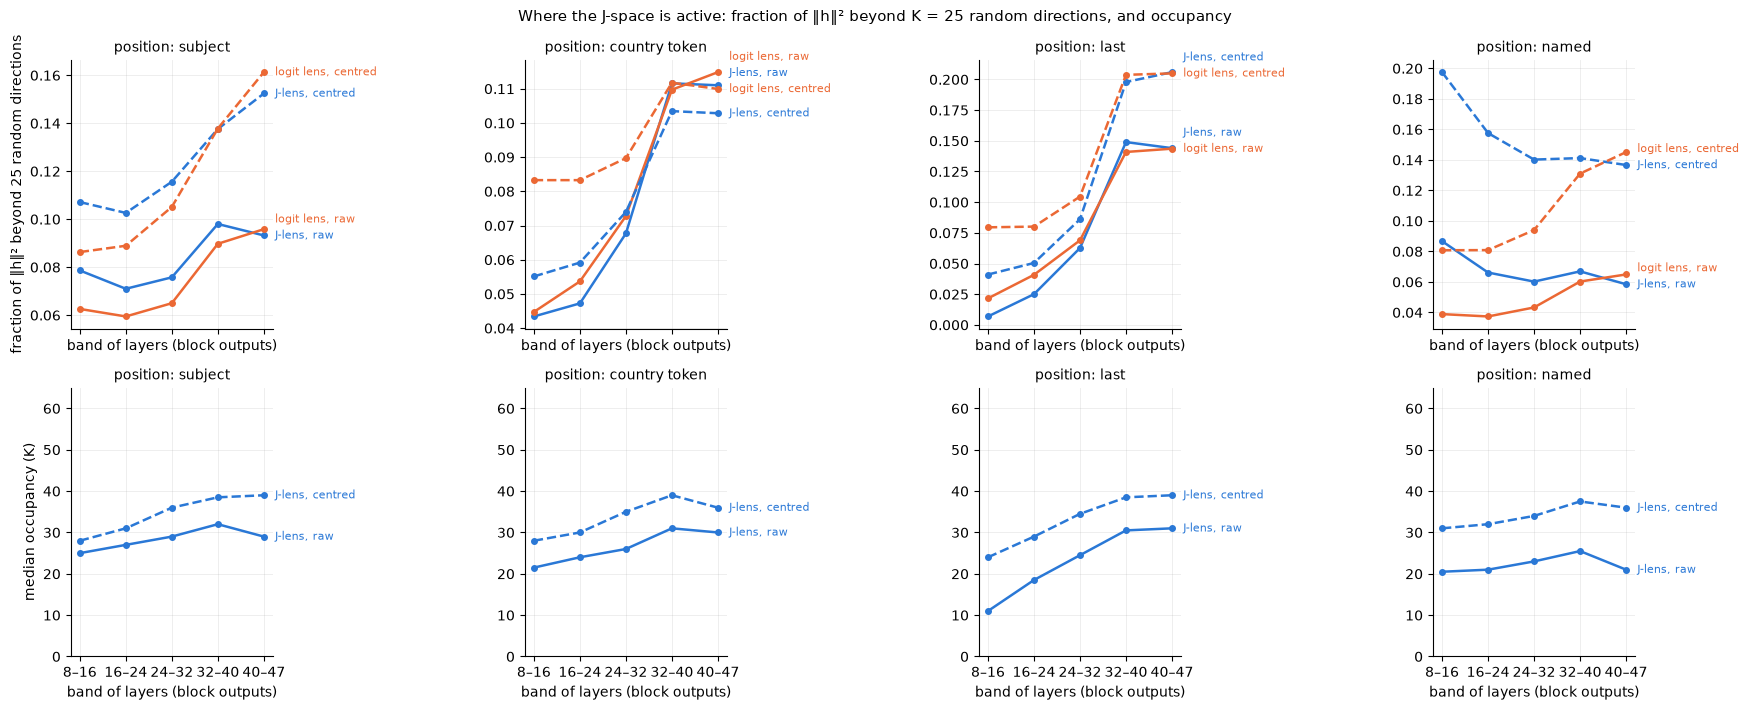

In [7]:
fig, axes = plt.subplots(2, len(POSITIONS), figsize=(4.4 * len(POSITIONS), 7.2), sharex=True)
for col, pos in enumerate(POSITIONS):
    for row, (metric, ylabel) in enumerate((("J excess over random set, K=25",
                                             "fraction of ‖h‖² beyond 25 random directions"),
                                            ("median occupancy", "median occupancy (K)"))):
        ax = axes[row, col]
        ends = []
        for variant, style in (("raw", "-"), ("centred", "--")):
            sub = active[active.variant.eq(variant) & active.position.eq(pos)].set_index("band").loc[BANDS]
            ax.plot(range(len(BANDS)), sub[metric], style, color=COLORS["J-lens"], marker="o", ms=4, lw=1.8)
            if row == 0:
                lsub = sub["logit excess over random set, K=25"]
                ax.plot(range(len(BANDS)), lsub, style, color=COLORS["logit lens"], marker="o", ms=4, lw=1.8)
                ends.append((lsub.iloc[-1], f"logit lens, {variant}", COLORS["logit lens"]))
            ends.append((sub[metric].iloc[-1], f"J-lens, {variant}", COLORS["J-lens"]))
        if row == 1:
            ax.set_ylim(0, K_MAX + 1)
        label_ends(ax, ends)
        band_axes(ax, ylabel if col == 0 else None)
        ax.set_title(f"position: {pos}", fontsize=10)
fig.suptitle("Where the J-space is active: fraction of ‖h‖² beyond K = 25 random directions, and occupancy",
             fontsize=11)
fig.tight_layout(w_pad=7)
plt.show()

Fraction of norm against K at the layer of each band's middle: J-lens and logit-lens
dictionaries, the best-of-50257 random control and K random directions (`K/d`); raw activations,
last subject token and named country token.

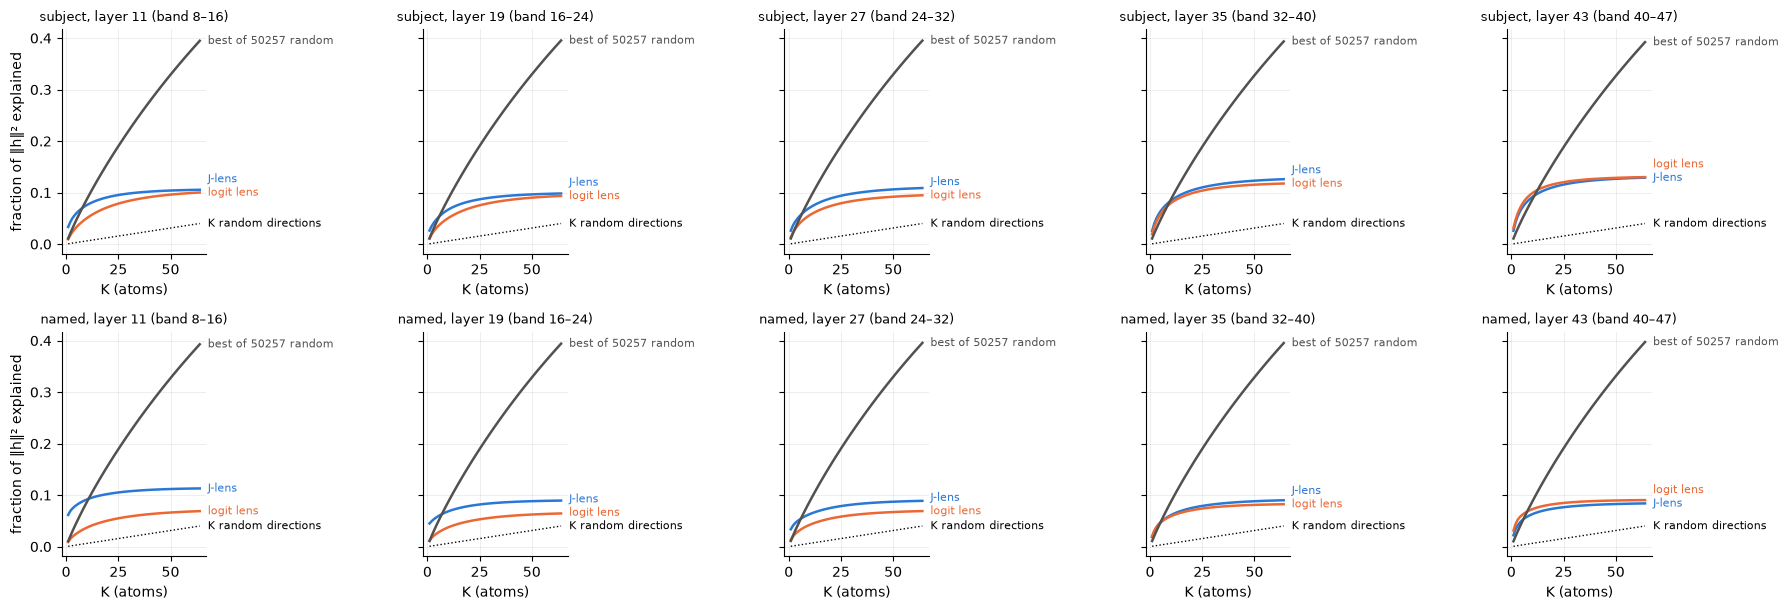

In [8]:
fig, axes = plt.subplots(2, len(BANDS), figsize=(3.6 * len(BANDS), 6.2), sharey=True)
for row, pos in enumerate(["subject", "named"]):
    for ax, band in zip(axes[row], BANDS, strict=True):
        lo, hi = map(int, band.split("-"))
        layer = (lo + hi - 1) // 2
        ends = []
        for name in DICTIONARIES:
            curve = curves[curves.variant.eq("raw") & curves.position.eq(pos) & curves.layer.eq(layer)
                           & curves.dictionary.eq(name)].fve.iloc[0]
            ax.plot(range(1, K_MAX + 1), curve, color=COLORS[name], lw=1.8)
            ends.append((curve[-1], {"random": "best of 50257 random"}.get(name, name), COLORS[name]))
        ks = np.arange(1, K_MAX + 1)
        ax.plot(ks, ks / D_MODEL, color="black", lw=1, ls=":")
        ends.append((K_MAX / D_MODEL, "K random directions", "black"))
        label_ends(ax, ends)
        ax.set_title(f"{pos}, layer {layer} (band {band.replace('-', '–')})", fontsize=9)
        ax.set_xlabel("K (atoms)")
        ax.grid(alpha=0.25, lw=0.6)
        ax.spines[["top", "right"]].set_visible(False)
    axes[row, 0].set_ylabel("fraction of ‖h‖² explained")
fig.tight_layout(w_pad=6)
plt.show()

## 4. Is the country in the J-space component?

Share of rows whose K selected J atoms (K from the band's occupancy) include a spelling of the
country, against a control country; J-lens and logit-lens dictionaries.

band                                             8-16  16-24  24-32  32-40  40-47
position      dictionary metric                                                  
subject       J-lens     control atom selected  0.003  0.000  0.001  0.000  0.000
                         country atom selected  0.058  0.157  0.218  0.319  0.318
              logit lens control atom selected  0.000  0.000  0.000  0.000  0.002
                         country atom selected  0.004  0.021  0.132  0.342  0.331
country token J-lens     control atom selected  0.012  0.027  0.034  0.010  0.003
                         country atom selected  0.029  0.044  0.254  0.486  0.452
              logit lens control atom selected  0.000  0.000  0.003  0.004  0.000
                         country atom selected  0.000  0.002  0.132  0.436  0.458
last          J-lens     control atom selected  0.002  0.000  0.001  0.000  0.000
                         country atom selected  0.001  0.000  0.002  0.039  0.031
              logit lens control atom selected  0.000  0.000  0.000  0.000  0.000
                         country atom selected  0.000  0.000  0.013  0.046  0.022
named         J-lens     control atom selected  0.024  0.009  0.000  0.000  0.000
                         country atom selected  1.000  1.000  0.997  0.874  0.699
              logit lens control atom selected  0.000  0.000  0.000  0.000  0.000
                         country atom selected  0.024  0.022  0.246  0.774  0.769

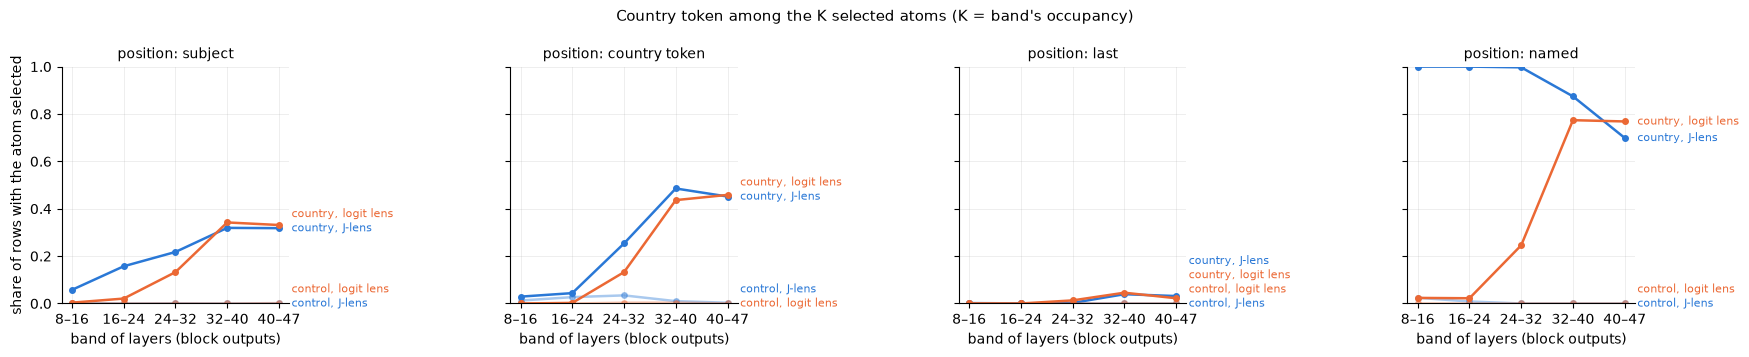

In [9]:
def at_band_k(frame, variant="raw"):
    # Rows of `frame` at the K chosen for each band.
    keep = [K_AT[variant, band] == k for band, k in zip(frame.band, frame.k, strict=True)]
    return frame[np.array(keep, dtype=bool)]


sel = at_band_k(metrics[metrics.variant.eq("raw") & metrics.metric.isin(["country atom selected",
                                                                         "control atom selected"])])
table = sel.groupby(["position", "dictionary", "metric", "band"]).value.mean().unstack("band")[BANDS]
display(table.reindex(POSITIONS, level="position").round(3))
fig, axes = plt.subplots(1, len(POSITIONS), figsize=(4.4 * len(POSITIONS), 3.6), sharey=True)
for ax, pos in zip(axes, POSITIONS, strict=True):
    ends = []
    for name in ["J-lens", "logit lens"]:
        for metric, alpha_, text in (("country atom selected", 1.0, "country"), ("control atom selected", 0.4,
                                                                                  "control")):
            sub = table.loc[(pos, name, metric)]
            ax.plot(range(len(BANDS)), sub.values, color=COLORS[name], alpha=alpha_, marker="o", ms=4, lw=1.8)
            ends.append((sub.values[-1], f"{text}, {name}", COLORS[name]))
    ax.set_ylim(0, 1)
    label_ends(ax, ends)
    band_axes(ax, "share of rows with the atom selected" if pos == POSITIONS[0] else None)
    ax.set_title(f"position: {pos}", fontsize=10)
fig.suptitle("Country token among the K selected atoms (K = band's occupancy)", fontsize=11)
fig.tight_layout(w_pad=8)
plt.show()

## 5. Is the J-space component of the country the same across prompts?

Mean cosine between prompts with the same country minus between prompts with different
countries, pairs from different subject families only. J-space component (J-lens), its logit
and random controls, the full residual and its non-J part; K from the band's occupancy.

band                                                    8-16  16-24  24-32  32-40  40-47
metric                       position      dictionary                                   
consistency                  subject       J-lens      0.034  0.040  0.055  0.056  0.030
                                           full h      0.026  0.032  0.038  0.044  0.029
                                           logit lens  0.008  0.007  0.019  0.035  0.022
                                           non-J part  0.019  0.025  0.027  0.029  0.019
                                           random      0.007  0.011  0.017  0.021  0.015
                             country token J-lens      0.004  0.003  0.009  0.016  0.012
                                           full h      0.001  0.002  0.005  0.011  0.009
                                           logit lens  0.004  0.004  0.006  0.011  0.008
                                           non-J part  0.001  0.002  0.003  0.007  0.005
                                           random      0.005  0.003  0.005  0.012  0.010
                             last          J-lens      0.002  0.002  0.014  0.090  0.122
                                           full h      0.000  0.001  0.004  0.043  0.070
                                           logit lens  0.003  0.002  0.015  0.087  0.114
                                           non-J part  0.000  0.001  0.003  0.030  0.052
                                           random      0.001 -0.000  0.009  0.072  0.109
consistency vs same language subject       J-lens      0.007  0.020  0.023  0.016  0.006
                                           full h      0.002  0.005  0.006  0.006  0.005
                                           logit lens -0.001  0.000  0.005  0.009  0.004
                                           non-J part  0.001  0.003  0.002  0.003  0.003
                                           random      0.001  0.000  0.004  0.002  0.003
                             country token J-lens     -0.001 -0.001  0.001  0.002 -0.000
                                           full h     -0.001 -0.002 -0.002 -0.002 -0.002
                                           logit lens -0.001 -0.001 -0.003 -0.002 -0.003
                                           non-J part -0.001 -0.002 -0.002 -0.002 -0.002
                                           random     -0.007 -0.004 -0.004  0.005  0.006
                             last          J-lens     -0.001 -0.000  0.005  0.020  0.032
                                           full h     -0.000 -0.000  0.001  0.010  0.021
                                           logit lens -0.002 -0.002  0.002  0.019  0.030
                                           non-J part -0.000 -0.000  0.001  0.008  0.017
                                           random     -0.001  0.000  0.000  0.015  0.039

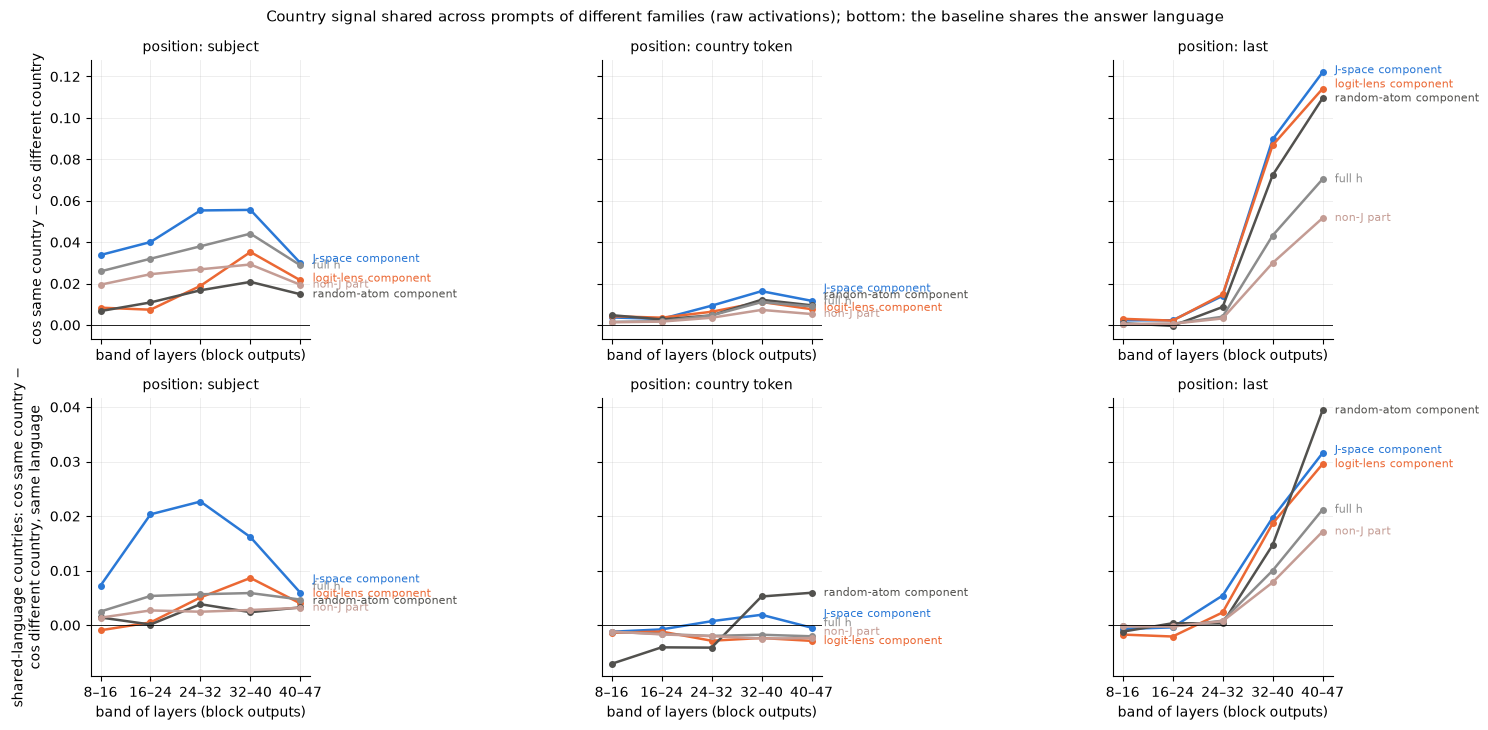

In [10]:
cons = at_band_k(metrics[metrics.variant.eq("raw") & metrics.metric.isin(["consistency",
                                                                          "consistency vs same language"])])
LINES = ["J-lens", "logit lens", "random", "full h", "non-J part"]
table = cons.groupby(["metric", "position", "dictionary", "band"]).value.mean().unstack("band")[BANDS]
display(table.reindex(POSITIONS[:3], level="position").round(3))
BASELINES = [("consistency", "cos same country − cos different country"),
             ("consistency vs same language", "shared-language countries: cos same country −\n"
                                              "cos different country, same language")]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.4), sharex=True, sharey="row")
for row_axes, (metric, ylabel) in zip(axes, BASELINES, strict=True):
    for ax, pos in zip(row_axes, POSITIONS[:3], strict=True):
        ends = []
        for name in LINES:
            sub = table.loc[(metric, pos, name)]
            ax.plot(range(len(BANDS)), sub.values, color=COLORS[name], marker="o", ms=4, lw=1.8)
            ends.append((sub.values[-1], {"J-lens": "J-space component", "logit lens": "logit-lens component",
                                          "random": "random-atom component"}.get(name, name), COLORS[name]))
        ax.axhline(0, color="black", lw=0.6)
        label_ends(ax, ends, gap=0.05)
        band_axes(ax, ylabel if pos == "subject" else None)
        ax.set_title(f"position: {pos}", fontsize=10)
fig.suptitle("Country signal shared across prompts of different families (raw activations); bottom: the "
             "baseline shares the answer language", fontsize=11)
fig.tight_layout(w_pad=10)
plt.show()

### Named vs latent

Each latent row is assigned the country whose named-template centroid (same layer, same
component) is most similar; top-1 accuracy among 22 (chance 0.045).

band                                                               8-16  16-24  24-32  32-40  40-47
metric                                  position      dictionary                                   
named-centroid accuracy                 subject       J-lens      0.555  0.713  0.758  0.780  0.506
                                                      full h      0.567  0.717  0.793  0.835  0.465
                                                      logit lens  0.130  0.152  0.299  0.552  0.433
                                                      non-J part  0.416  0.599  0.712  0.738  0.321
                                                      random      0.128  0.192  0.255  0.341  0.185
                                        country token J-lens      0.118  0.105  0.207  0.361  0.204
                                                      full h      0.071  0.102  0.175  0.227  0.181
                                                      logit lens  0.063  0.090  0.144  0.272  0.153
                                                      non-J part  0.098  0.086  0.109  0.113  0.119
                                                      random      0.032  0.066  0.044  0.082  0.079
                                        last          J-lens      0.051  0.063  0.192  0.712  0.404
                                                      full h      0.024  0.028  0.105  0.629  0.699
                                                      logit lens  0.033  0.031  0.145  0.592  0.461
                                                      non-J part  0.014  0.044  0.064  0.287  0.544
                                                      random      0.048  0.065  0.091  0.139  0.128
named-centroid accuracy within language subject       J-lens      0.699  0.820  0.834  0.802  0.637
                                                      full h      0.748  0.875  0.880  0.858  0.689
                                                      logit lens  0.426  0.456  0.494  0.630  0.635
                                                      non-J part  0.641  0.788  0.834  0.843  0.646
                                                      random      0.437  0.544  0.625  0.628  0.465
                                        country token J-lens      0.426  0.489  0.606  0.598  0.495
                                                      full h      0.506  0.536  0.582  0.614  0.490
                                                      logit lens  0.377  0.389  0.397  0.449  0.452
                                                      non-J part  0.506  0.525  0.491  0.547  0.441
                                                      random      0.487  0.508  0.457  0.454  0.378
                                        last          J-lens      0.367  0.366  0.429  0.606  0.526
                                                      full h      0.483  0.506  0.517  0.726  0.803
                                                      logit lens  0.460  0.381  0.427  0.565  0.494
                                                      non-J part  0.506  0.509  0.489  0.658  0.756
                                                      random      0.407  0.413  0.502  0.525  0.474

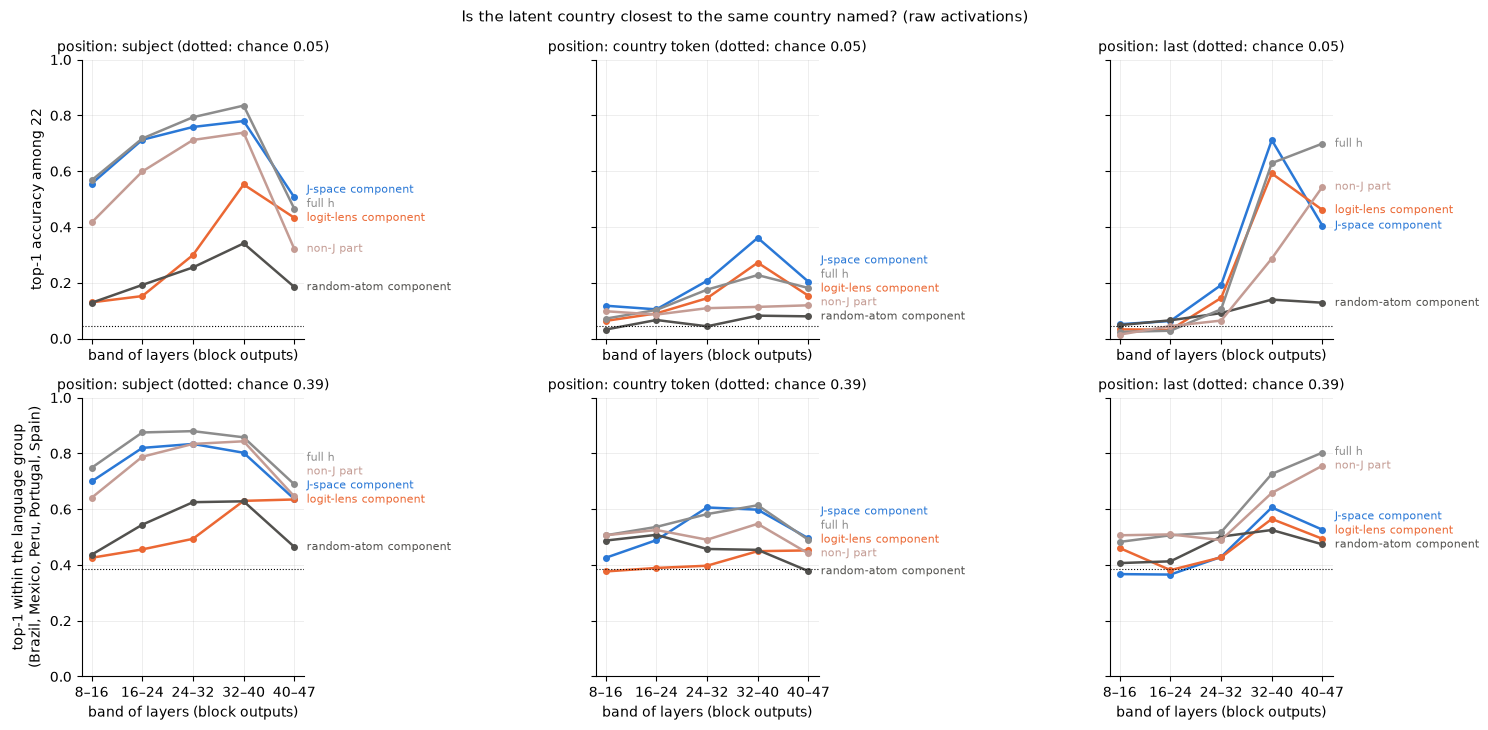

In [11]:
acc = at_band_k(metrics[metrics.variant.eq("raw") & metrics.metric.isin(
    ["named-centroid accuracy", "named-centroid accuracy within language"])])
table = acc.groupby(["metric", "position", "dictionary", "band"]).value.mean().unstack("band")[BANDS]
display(table.reindex(POSITIONS[:3], level="position").round(3))
SHARED_COUNTRIES = [c for c in COUNTRIES if sum(LANG[o] == LANG[c] for o in COUNTRIES) > 1]
n_shared = sites[sites.position.eq("subject") & sites.country.isin(SHARED_COUNTRIES)]
chance_within = np.mean([1 / sum(LANG[o] == LANG[c] for o in COUNTRIES) for c in n_shared.country])
ACCURACY_ROWS = [("named-centroid accuracy", "top-1 accuracy among 22", 1 / len(COUNTRIES)),
                 ("named-centroid accuracy within language",
                  f"top-1 within the language group\n({', '.join(SHARED_COUNTRIES)})", chance_within)]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.4), sharex=True, sharey=True)
for row_axes, (metric, ylabel, chance) in zip(axes, ACCURACY_ROWS, strict=True):
    for ax, pos in zip(row_axes, POSITIONS[:3], strict=True):
        ends = []
        for name in LINES:
            sub = table.loc[(metric, pos, name)]
            ax.plot(range(len(BANDS)), sub.values, color=COLORS[name], marker="o", ms=4, lw=1.8)
            ends.append((sub.values[-1], {"J-lens": "J-space component", "logit lens": "logit-lens component",
                                          "random": "random-atom component"}.get(name, name), COLORS[name]))
        ax.axhline(chance, color="black", lw=0.8, ls=":")
        ax.set_ylim(0, 1)
        label_ends(ax, ends, gap=0.05)
        band_axes(ax, ylabel if pos == "subject" else None)
        ax.set_title(f"position: {pos} (dotted: chance {chance:.2f})", fontsize=10)
fig.suptitle("Is the latent country closest to the same country named? (raw activations)", fontsize=11)
fig.tight_layout(w_pad=10)
plt.show()

### Sensitivity to K and to centring

J-space consistency and named-centroid accuracy at every K of the grid, raw and centred, at the
last subject token.

In [12]:
sub = metrics[metrics.dictionary.eq("J-lens") & metrics.position.eq("subject")
              & metrics.metric.isin(["consistency", "consistency vs same language", "named-centroid accuracy",
                                     "named-centroid accuracy within language", "country atom selected"])]
sub.groupby(["metric", "variant", "k", "band"]).value.mean().unstack("band")[BANDS].round(3)

band                                                   8-16  16-24  24-32  32-40  40-47
metric                                  variant k                                      
consistency                             centred 2.0   0.029  0.038  0.054  0.064  0.035
                                                4.0   0.030  0.040  0.059  0.070  0.042
                                                8.0   0.031  0.040  0.061  0.072  0.046
                                                16.0  0.032  0.040  0.059  0.071  0.049
                                                25.0  0.032  0.039  0.058  0.070  0.050
...                                                     ...    ...    ...    ...    ...
named-centroid accuracy within language raw     8.0   0.663  0.793  0.791  0.764  0.665
                                                16.0  0.707  0.816  0.839  0.772  0.671
                                                25.0  0.699  0.820  0.834  0.804  0.642
                                                32.0  0.699  0.820  0.845  0.802  0.637
                                                64.0  0.698  0.821  0.834  0.799  0.617

[70 rows x 5 columns]

## 6. Probe directions in J-space

Fraction of each difference-of-means probe vector `w_c` explained by K atoms of each dictionary,
mean over the 22 countries and the layers of each band.

K random directions explain K/d: {'K=2': 0.0013, 'K=4': 0.0025, 'K=8': 0.005, 'K=16': 0.01, 'K=25': 0.0156, 'K=32': 0.02, 'K=64': 0.04}


K=2    K=4    K=8   K=16   K=25   K=32   K=64
dictionary band                                                  
J-lens     8-16   0.156  0.175  0.200  0.227  0.242  0.248  0.257
           16-24  0.126  0.144  0.167  0.192  0.207  0.213  0.223
           24-32  0.104  0.121  0.143  0.166  0.181  0.187  0.199
           32-40  0.084  0.103  0.125  0.149  0.164  0.171  0.185
           40-47  0.076  0.098  0.122  0.147  0.161  0.168  0.181
logit lens 8-16   0.024  0.037  0.055  0.080  0.097  0.106  0.125
           16-24  0.026  0.039  0.057  0.081  0.098  0.107  0.125
           24-32  0.035  0.049  0.069  0.093  0.109  0.118  0.136
           32-40  0.063  0.080  0.101  0.126  0.142  0.150  0.167
           40-47  0.076  0.098  0.122  0.148  0.164  0.172  0.187
random     8-16   0.022  0.041  0.074  0.133  0.192  0.234  0.395
           16-24  0.022  0.040  0.073  0.133  0.192  0.234  0.397
           24-32  0.021  0.040  0.073  0.132  0.191  0.234  0.397
           32-40  0.021  0.039  0.073  0.133  0.192  0.234  0.397
           40-47  0.021  0.040  0.073  0.132  0.192  0.234  0.397

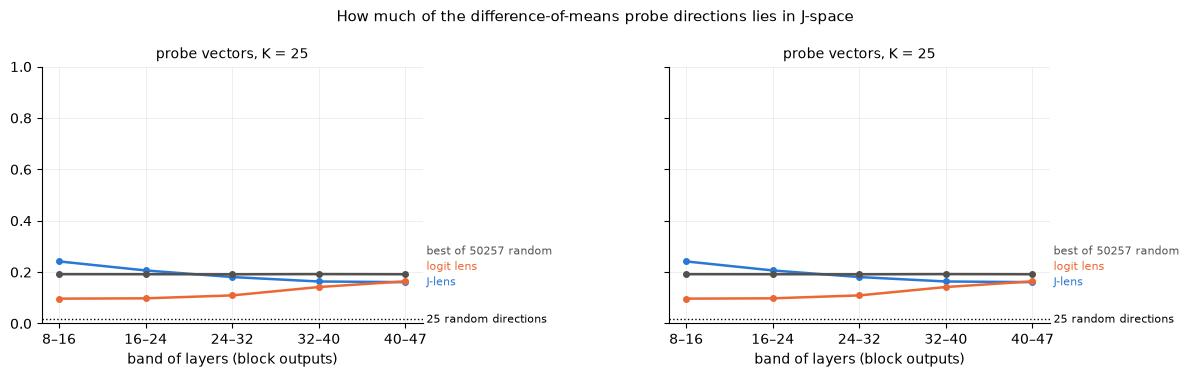

In [13]:
rows = []
for (band, name), group in probe_fve.groupby(["band", "dictionary"]):
    stacked = np.stack(group.fve.to_numpy()).mean(0)
    rows.append({"band": band, "dictionary": name, **{f"K={k}": stacked[k - 1] for k in K_GRID}})
probe_table = pd.DataFrame(rows).set_index(["dictionary", "band"]).reindex(DICTIONARIES, level="dictionary")
print("K random directions explain K/d:", {f"K={k}": round(k / D_MODEL, 4) for k in K_GRID})
display(probe_table.reindex(BANDS, level="band").round(3))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, k in zip(axes, [K_AT["raw", BANDS[2]], 25], strict=True):
    ends = []
    for name in DICTIONARIES:
        values = probe_table.loc[name].loc[BANDS, f"K={k}"].to_numpy()
        ax.plot(range(len(BANDS)), values, color=COLORS[name], marker="o", ms=4, lw=1.8)
        ends.append((values[-1], {"random": "best of 50257 random"}.get(name, name), COLORS[name]))
    ax.axhline(k / D_MODEL, color="black", lw=1, ls=":")
    ends.append((k / D_MODEL, f"{k} random directions", "black"))
    ax.set_ylim(0, 1)
    label_ends(ax, ends)
    band_axes(ax, "fraction of ‖w_c‖² explained" if k != 25 else None)
    ax.set_title(f"probe vectors, K = {k}", fontsize=10)
fig.suptitle("How much of the difference-of-means probe directions lies in J-space", fontsize=11)
fig.tight_layout(w_pad=8)
plt.show()

## 7. How much a concept's projection varies across prompts

For each country separately, over all its prompts at one position and layer (Japan: Toyota,
Osaka, sushi, …; named: the 20 templates), no comparison with other countries:

* **Along the concept's own direction.** `a = h · v̂_c` with `v̂_c` the unit J-lens vector of
  the country's token; per prompt the fraction `a / ‖h‖`, then its mean and standard deviation
  over the country's prompts, and the coefficient of variation `sd(a) / mean(a)`. Controls: the
  unit logit-lens direction of the same token, and a random unit direction per country (mean ≈ 0,
  sd ≈ 1/√d ≈ 0.025).
* **The whole J-space component.** `h_J` from the pursuit at K = 25; relative dispersion
  `E‖h_J − mean_c h_J‖² / E‖h_J‖²` over the country's prompts: 0 if every prompt gives the same
  vector, 1 if they share nothing. Also for the full residual `h` and the logit-lens component.
* **The share of the norm in J-space** `‖h_J‖² / ‖h‖²`: mean, sd and coefficient of variation
  over the country's prompts.
* **The concept's coordinate in J-space**: the coefficient of the country's atom (any whole-token
  spelling) in the decomposition, divided by `‖h‖`. Share of prompts where it is non-zero; its
  mean and coefficient of variation where it is non-zero, and over all prompts (zeros included).
  Same for the logit-lens dictionary.

Countries with at least 5 prompts at the position; medians over countries, then means over the
layers of a band. Raw activations. Own cache (`VAR_CACHE`); one model pass and two pursuits per
layer.

In [14]:
VAR_CACHE = OUT_DIR / "latent_bridge_v2_concept_variance.pkl"
MIN_PROMPTS = 5
K_VAR = 25
if not VAR_CACHE.exists():
    hf_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float32).to(DEVICE).eval()
    model = jlens.from_hf(hf_model, tokenizer, compile=False, force_bos=False)
    lens = jlens.JacobianLens.load(str(LENS_PATH))
    g = hf_model.transformer.ln_f.weight.float()[None] * hf_model.get_output_embeddings().weight.float()
    if final_norm_centers(model):
        g = g - g.mean(1, keepdim=True)
    logit_dictionary = F.normalize(g, dim=1)
    country_token = torch.tensor([tokenizer.encode(" " + c)[0] for c in COUNTRIES], device=DEVICE)
    spellings = DecodedSpellings(tokenizer, vocab_size=g.shape[0])
    is_country_atom = torch.zeros(len(COUNTRIES), g.shape[0], dtype=torch.bool, device=DEVICE)
    for c, name_c in enumerate(COUNTRIES):
        is_country_atom[c, sorted(spellings(name_c, False))] = True
    generator = torch.Generator(device=DEVICE).manual_seed(SEED + 1)
    random_directions = F.normalize(torch.randn(len(COUNTRIES), model.d_model, generator=generator, device=DEVICE),
                                    dim=1)
    H = {layer: torch.empty(len(sites), model.d_model, device=DEVICE) for layer in LAYERS}
    order = np.argsort(sites.ids.map(len).to_numpy(), kind="stable")
    with torch.no_grad():
        for start in tqdm(range(0, len(order), BATCH_SIZE), desc="activations"):
            index = order[start:start + BATCH_SIZE]
            chunk = sites.iloc[index]
            ids = pad_sequence([torch.tensor(i) for i in chunk.ids], batch_first=True,
                               padding_value=tokenizer.eos_token_id).to(DEVICE)
            with ActivationRecorder(model.layers, at=LAYERS) as recorder:
                hf_model(input_ids=ids)
            rows = torch.arange(len(index), device=DEVICE)
            positions = torch.tensor(chunk["index"].to_numpy(), device=DEVICE)
            for layer in LAYERS:
                H[layer][torch.tensor(index, device=DEVICE)] = recorder.activations[layer][rows, positions].float()
            del recorder
    country = torch.tensor(sites.country.map(COUNTRIES.index).to_numpy(), device=DEVICE)
    position = torch.tensor(sites.position.map(POSITIONS.index).to_numpy(), device=DEVICE)
    var_rows = []
    for layer in tqdm(LAYERS, desc="layers"):
        J = lens.jacobians[layer].to(DEVICE, torch.float32)
        j_dictionary = F.normalize(g @ J, dim=1)
        X = H[layer]
        norms = X.norm(dim=1)
        directions = {"J-lens direction": j_dictionary[country_token], "logit-lens direction":
                      logit_dictionary[country_token], "random direction": random_directions}
        vectors, coordinates = {"full h": X}, {}
        row_atoms = is_country_atom[country]  # [rows, vocab]: atoms that spell the row's country
        for space, component, D in (("J-space", "J-space component", j_dictionary),
                                    ("logit-lens space", "logit-lens component", logit_dictionary)):
            _, support, snapshots = pursuit(X, D, K_VAR, snapshots=[K_VAR])
            vectors[component], coef = snapshots[K_VAR]
            coordinates[space] = (coef * row_atoms.gather(1, support[:, :K_VAR])).sum(1) / norms
        del row_atoms
        for p, pos in enumerate(POSITIONS):
            for c, name_c in enumerate(COUNTRIES):
                m = (position == p) & (country == c)
                n = int(m.sum())
                if n < MIN_PROMPTS:
                    continue
                record = {"layer": layer, "position": pos, "country": name_c, "prompts": n}
                for name, D in directions.items():
                    a = X[m] @ D[c]
                    fraction = a / norms[m]
                    record[f"{name}: mean fraction"] = fraction.mean().item()
                    record[f"{name}: sd fraction"] = fraction.std().item()
                    record[f"{name}: cv"] = (a.std() / a.mean().abs()).item()
                for name, V in vectors.items():
                    Y = V[m]
                    energy = (Y * Y).sum(1).mean()
                    spread = ((Y - Y.mean(0)) ** 2).sum(1).mean()
                    record[f"{name}: relative dispersion"] = (spread / energy).item()
                    share = (Y * Y).sum(1) / norms[m] ** 2
                    record[f"{name}: fraction of norm"] = share.mean().item()
                    record[f"{name}: fraction of norm sd"] = share.std().item()
                    record[f"{name}: fraction of norm cv"] = (share.std() / share.mean()).item()
                for space, coordinate in coordinates.items():
                    v = coordinate[m]
                    present = v > 0
                    record[f"{space}: coordinate present"] = present.float().mean().item()
                    record[f"{space}: coordinate mean (all)"] = v.mean().item()
                    record[f"{space}: coordinate cv (all)"] = (v.std() / v.mean()).item() if v.mean() > 0 else np.nan
                    if present.sum() >= 2:
                        record[f"{space}: coordinate mean (present)"] = v[present].mean().item()
                        record[f"{space}: coordinate cv (present)"] = (v[present].std() / v[present].mean()).item()
                var_rows.append(record)
        del J, j_dictionary, vectors
        torch.cuda.empty_cache()
    pd.to_pickle({"rows": pd.DataFrame(var_rows), "k": K_VAR, "min_prompts": MIN_PROMPTS, "seed": SEED + 1,
                  "lens": str(LENS_PATH), "model": MODEL_ID}, VAR_CACHE)
    model = hf_model = lens = H = None
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
variance = pd.read_pickle(VAR_CACHE)["rows"]
variance["band"] = variance.layer.map(band_of)
print(variance.groupby("position").country.nunique().rename("countries with >= 5 prompts").to_string())
by_band = variance.drop(columns="country").groupby(["position", "band", "layer"]).median().groupby(
    ["position", "band"]).mean()
SCALAR = ["J-lens direction", "logit-lens direction", "random direction"]
COMPONENTS = ["J-space component", "logit-lens component", "full h"]
SPACES = ["J-space", "logit-lens space"]
columns = ([f"{d}: {s}" for d in SCALAR for s in ("mean fraction", "sd fraction", "cv")]
           + [f"{v}: {s}" for v in COMPONENTS for s in ("fraction of norm", "relative dispersion")])
display(by_band[columns].reindex(POSITIONS, level="position").reindex(BANDS, level="band").round(3))
print("J-space share of the norm and the concept's J-space coordinate, per country across its prompts:")
columns = ([f"{v}: fraction of norm{s}" for v in COMPONENTS[:2] for s in ("", " sd", " cv")]
           + [f"{sp}: coordinate {s}" for sp in SPACES for s in ("present", "mean (present)", "cv (present)",
                                                                 "mean (all)", "cv (all)")])
by_band[columns].reindex(POSITIONS, level="position").reindex(BANDS, level="band").round(3)

position
country token    21
last             21
named            22
subject          21


J-lens direction: mean fraction  J-lens direction: sd fraction  J-lens direction: cv  logit-lens direction: mean fraction  logit-lens direction: sd fraction  logit-lens direction: cv  random direction: mean fraction  \
position      band                                                                                                                                                                                                                             
subject       8-16                             0.062                          0.038                 0.778                               -0.000                              0.021                     2.898                           -0.006   
              16-24                            0.082                          0.033                 0.455                                0.014                              0.021                     1.594                           -0.006   
              24-32                            0.096                          0.036                 0.395                                0.041                              0.023                     0.619                           -0.006   
              32-40                            0.113                          0.033                 0.300                                0.077                              0.029                     0.416                           -0.011   
              40-47                            0.084                          0.025                 0.299                                0.057                              0.024                     0.510                           -0.007   
country token 8-16                             0.046                          0.008                 0.205                                0.003                              0.007                     0.857                           -0.014   
              16-24                            0.050                          0.010                 0.223                                0.018                              0.008                     0.536                           -0.011   
              24-32                            0.073                          0.014                 0.216                                0.043                              0.013                     0.377                           -0.006   
              32-40                            0.095                          0.016                 0.194                                0.065                              0.017                     0.291                           -0.003   
              40-47                            0.074                          0.014                 0.230                                0.047                              0.014                     0.357                           -0.005   
last          8-16                             0.007                          0.002                 0.201                                0.003                              0.002                     0.325                           -0.007   
              16-24                            0.019                          0.003                 0.149                                0.005                              0.003                     0.291                           -0.011   
              24-32                            0.045                          0.008                 0.160                                0.035                              0.009                     0.234                           -0.009   
              32-40                            0.147                          0.024                 0.161                                0.115                              0.024                     0.215                           -0.006   
              40-47                            0.142                          0.018                 0.116                                0.106                              0.018    

J-space share of the norm and the concept's J-space coordinate, per country across its prompts:


J-space component: fraction of norm  J-space component: fraction of norm sd  J-space component: fraction of norm cv  logit-lens component: fraction of norm  logit-lens component: fraction of norm sd  \
position      band                                                                                                                                                                                                            
subject       8-16                                 0.093                                   0.025                                   0.265                                   0.078                                      0.009   
              16-24                                0.086                                   0.015                                   0.177                                   0.075                                      0.009   
              24-32                                0.091                                   0.012                                   0.133                                   0.081                                      0.010   
              32-40                                0.114                                   0.016                                   0.140                                   0.106                                      0.018   
              40-47                                0.110                                   0.020                                   0.183                                   0.112                                      0.023   
country token 8-16                                 0.059                                   0.003                                   0.057                                   0.060                                      0.003   
              16-24                                0.063                                   0.004                                   0.055                                   0.069                                      0.004   
              24-32                                0.083                                   0.007                                   0.086                                   0.089                                      0.008   
              32-40                                0.127                                   0.013                                   0.098                                   0.125                                      0.013   
              40-47                                0.127                                   0.012                                   0.096                                   0.131                                      0.013   
last          8-16                                 0.023                                   0.001                                   0.044                                   0.037                                      0.001   
              16-24                                0.041                                   0.001                                   0.036                                   0.056                                      0.001   
              24-32                                0.078                                   0.003                                   0.039                                   0.085                                      0.003   
              32-40                                0.166                                   0.008                                   0.050                                   0.158                                      0.008   
              40-47                                0.163                                   0.010                                   0.059                                   0.161                                      0.009   
named         8-16                                 0.104                                   0.003                                   0.033                                   0.054                                      0.002   
       

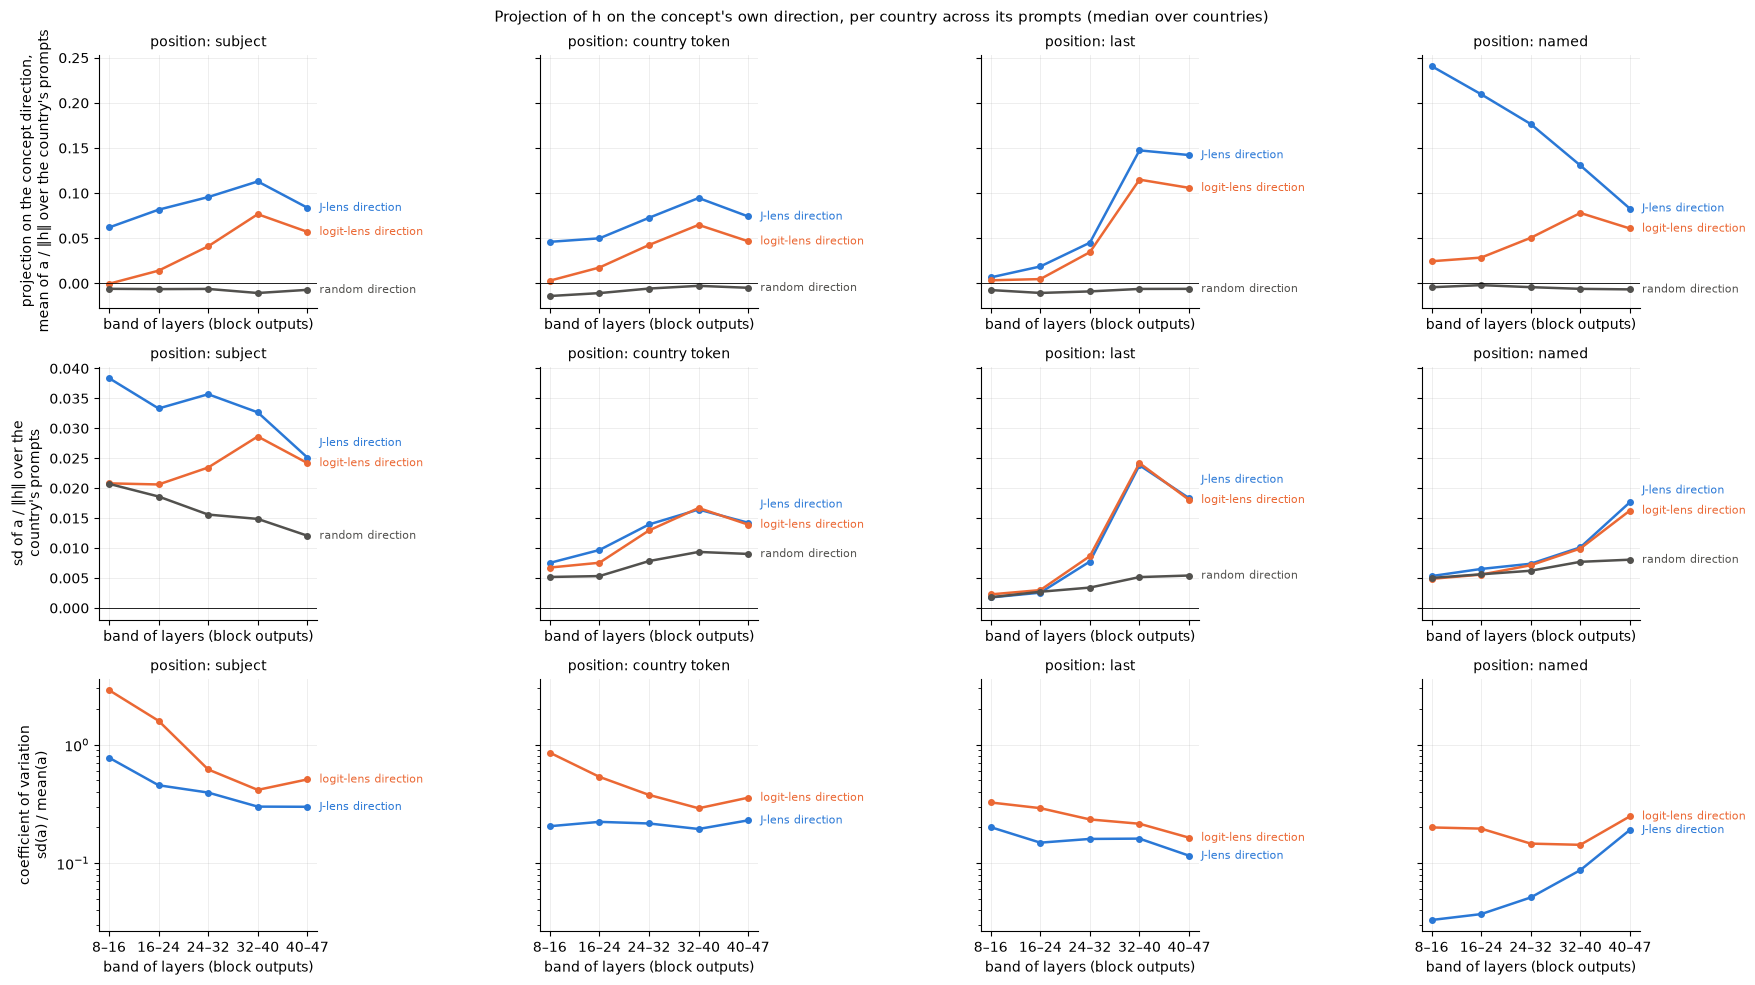

In [15]:
DIRECTION_COLORS = {"J-lens direction": COLORS["J-lens"], "logit-lens direction": COLORS["logit lens"],
                    "random direction": COLORS["random"]}
fig, axes = plt.subplots(3, len(POSITIONS), figsize=(4.4 * len(POSITIONS), 10), sharex=True, sharey="row")
ROWS = [("mean fraction", "projection on the concept direction,\nmean of a / ‖h‖ over the country's prompts"),
        ("sd fraction", "sd of a / ‖h‖ over the\ncountry's prompts"),
        ("cv", "coefficient of variation\nsd(a) / mean(a)")]
for row_axes, (stat, ylabel) in zip(axes, ROWS, strict=True):
    for ax, pos in zip(row_axes, POSITIONS, strict=True):
        ends = []
        for name, color in DIRECTION_COLORS.items():
            if stat == "cv" and name == "random direction":
                continue  # mean ≈ 0: the ratio is meaningless
            values = by_band.loc[pos].loc[BANDS, f"{name}: {stat}"].to_numpy()
            ax.plot(range(len(BANDS)), values, color=color, marker="o", ms=4, lw=1.8)
            ends.append((values[-1], name, color))
        if stat == "cv":
            ax.set_yscale("log")
        else:
            ax.axhline(0, color="black", lw=0.6)
        label_ends(ax, ends, gap=0.08 if stat != "cv" else 0.0)
        band_axes(ax, ylabel if pos == POSITIONS[0] else None)
        ax.set_title(f"position: {pos}", fontsize=10)
fig.suptitle("Projection of h on the concept's own direction, per country across its prompts "
             "(median over countries)", fontsize=11)
fig.tight_layout(w_pad=8)
plt.show()

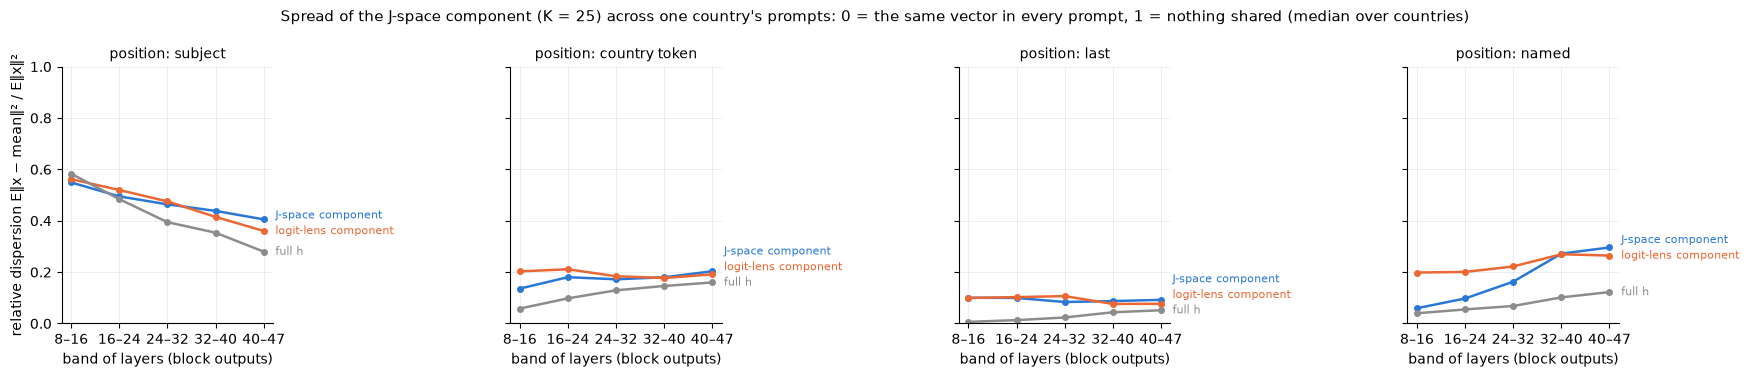

In [16]:
COMPONENT_COLORS = {"J-space component": COLORS["J-lens"], "logit-lens component": COLORS["logit lens"],
                    "full h": COLORS["full h"]}
fig, axes = plt.subplots(1, len(POSITIONS), figsize=(4.4 * len(POSITIONS), 3.8), sharey=True)
for ax, pos in zip(axes, POSITIONS, strict=True):
    ends = []
    for name, color in COMPONENT_COLORS.items():
        values = by_band.loc[pos].loc[BANDS, f"{name}: relative dispersion"].to_numpy()
        ax.plot(range(len(BANDS)), values, color=color, marker="o", ms=4, lw=1.8)
        ends.append((values[-1], name, color))
    ax.set_ylim(0, 1)
    label_ends(ax, ends)
    band_axes(ax, "relative dispersion E‖x − mean‖² / E‖x‖²" if pos == POSITIONS[0] else None)
    ax.set_title(f"position: {pos}", fontsize=10)
fig.suptitle(f"Spread of the J-space component (K = {K_VAR}) across one country's prompts: 0 = the same "
             "vector in every prompt, 1 = nothing shared (median over countries)", fontsize=11)
fig.tight_layout(w_pad=8)
plt.show()

The projection on J-space itself, per country across its prompts: the share of `‖h‖²` it takes
and the country's own coordinate in it (J-space vs the logit-lens dictionary's space).

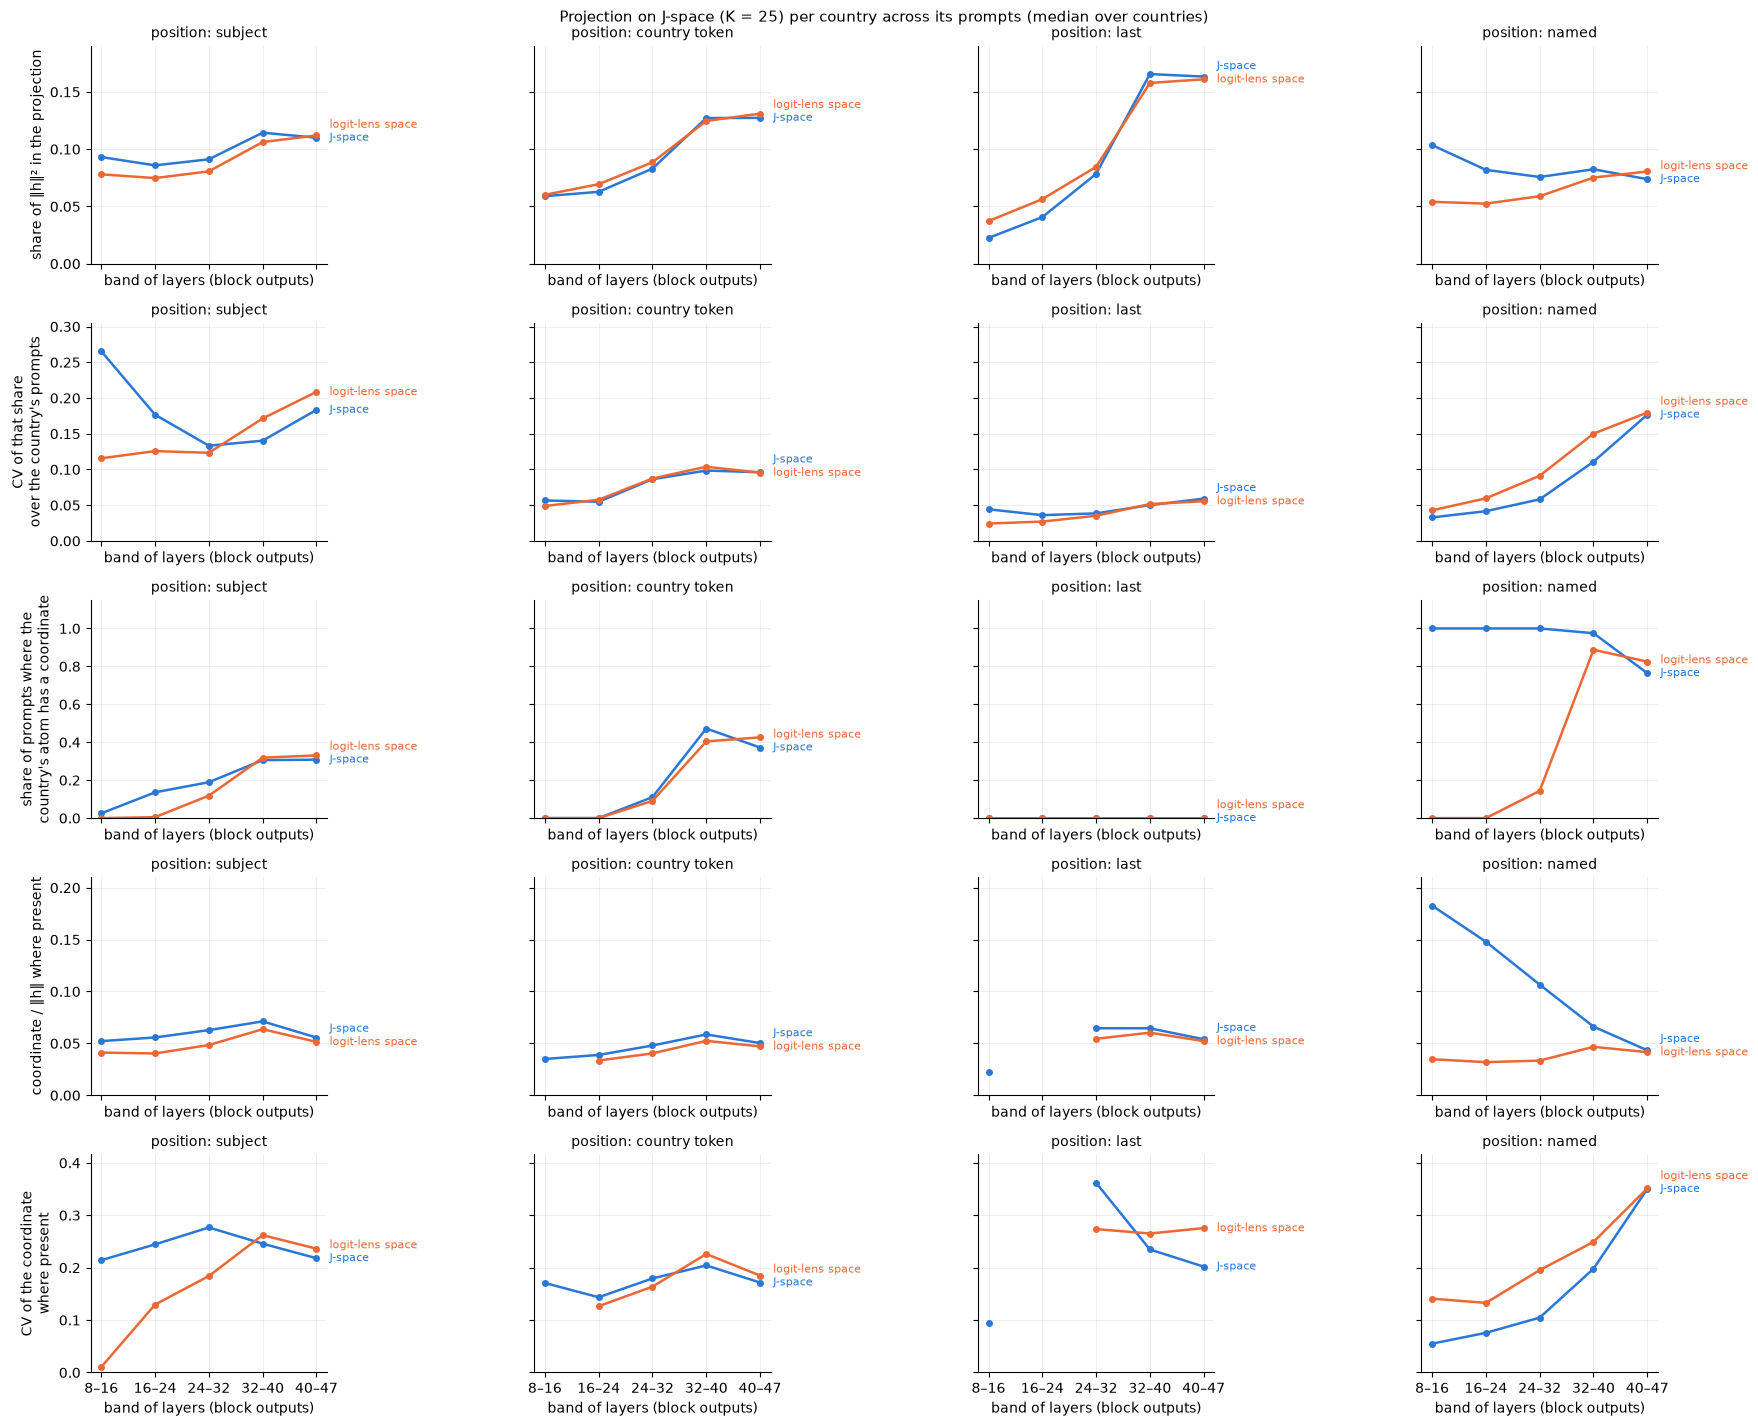

In [17]:
SPACE_COLORS = {"J-space": COLORS["J-lens"], "logit-lens space": COLORS["logit lens"]}
PANELS = [("J-space component: fraction of norm", "logit-lens component: fraction of norm",
           "share of ‖h‖² in the projection"),
          ("J-space component: fraction of norm cv", "logit-lens component: fraction of norm cv",
           "CV of that share\nover the country's prompts"),
          ("J-space: coordinate present", "logit-lens space: coordinate present",
           "share of prompts where the\ncountry's atom has a coordinate"),
          ("J-space: coordinate mean (present)", "logit-lens space: coordinate mean (present)",
           "coordinate / ‖h‖ where present"),
          ("J-space: coordinate cv (present)", "logit-lens space: coordinate cv (present)",
           "CV of the coordinate\nwhere present")]
fig, axes = plt.subplots(len(PANELS), len(POSITIONS), figsize=(4.4 * len(POSITIONS), 2.9 * len(PANELS)),
                         sharex=True, sharey="row")
for row_axes, (j_column, l_column, ylabel) in zip(axes, PANELS, strict=True):
    for ax, pos in zip(row_axes, POSITIONS, strict=True):
        ends = []
        for column, space in ((j_column, "J-space"), (l_column, "logit-lens space")):
            values = by_band.loc[pos].loc[BANDS, column].to_numpy(dtype=float).copy()
            values[~np.isfinite(values)] = np.nan
            ax.plot(range(len(BANDS)), values, color=SPACE_COLORS[space], marker="o", ms=4, lw=1.8)
            finite = values[np.isfinite(values)]
            if len(finite):
                ends.append((finite[-1], space, SPACE_COLORS[space]))
        top = np.nanmax(by_band[[j_column, l_column]].replace([np.inf, -np.inf], np.nan).to_numpy(dtype=float))
        ax.set_ylim(0, 1.15 * top if np.isfinite(top) and top > 0 else 1)
        label_ends(ax, ends)
        band_axes(ax, ylabel if pos == POSITIONS[0] else None)
        ax.set_title(f"position: {pos}", fontsize=10)
fig.suptitle(f"Projection on J-space (K = {K_VAR}) per country across its prompts (median over countries)",
             fontsize=11)
fig.tight_layout(w_pad=8)
plt.show()

Per country, last subject token and named country, layers 24–32 (J-lens direction and J-space):

In [18]:
per_country = variance[variance.band.eq("24-32") & variance.position.isin(["subject", "named"])].groupby(
    ["position", "country"])[["prompts", "J-lens direction: mean fraction", "J-lens direction: cv",
                              "J-space component: relative dispersion", "J-space component: fraction of norm cv",
                              "J-space: coordinate present", "J-space: coordinate mean (present)",
                              "J-space: coordinate cv (present)"]].mean()
per_country.unstack("position").round(3)

prompts         J-lens direction: mean fraction         J-lens direction: cv         J-space component: relative dispersion         J-space component: fraction of norm cv         J-space: coordinate present          \
position      named subject                           named subject                named subject                                  named subject                                  named subject                       named subject   
country                                                                                                                                                                                                                              
Brazil         20.0    18.0                           0.199   0.102                0.048   0.399                                  0.132   0.462                                  0.052   0.139                       1.000   0.188   
China          20.0     5.0                           0.171   0.080                0.069   0.593                                  0.161   0.435                                  0.057   0.072                       1.000   0.000   
Egypt          20.0    14.0                           0.178   0.091                0.047   0.366                                  0.144   0.484                                  0.065   0.150                       1.000   0.295   
England        20.0    24.0                           0.177   0.087                0.058   0.278                                  0.158   0.533                                  0.065   0.145                       1.000   0.161   
France         20.0    33.0                           0.178   0.085                0.048   0.346                                  0.174   0.517                                  0.059   0.130                       1.000   0.170   
Germany        20.0    28.0                           0.178   0.095                0.047   0.457                                  0.182   0.533                                  0.053   0.137                       1.000   0.174   
Greece         20.0    12.0                           0.171   0.099                0.055   0.281                                  0.178   0.446                                  0.068   0.112                       1.000   0.135   
India          20.0    16.0                           0.150   0.091                0.062   0.290                                  0.190   0.500                                  0.062   0.190                       1.000   0.156   
Israel         20.0     7.0                           0.149   0.100                0.053   0.228                                  0.182   0.389                                  0.055   0.108                       0.994   0.000   
Italy          20.0    25.0                           0.176   0.107                0.053   0.306                                  0.163   0.492                                  0.061   0.129                       1.000   0.275   
Japan          20.0    29.0                           0.176   0.108                0.053   0.354                                  0.153   0.500                                  0.053   0.126                       1.000   0.254   
Korea          20.0    12.0                           0.173   0.109                0.051   0.399                                  0.183   0.408                                  0.051   0.110                       0.956   0.115   
Mexico         20.0    22.0                           0.193   0.114                0.063   0.308                                  0.127   0.436                                  0.069   0.150                       1.000   0.318   
Netherlands    20.0    10.0                           0.179   0.097                0.038   0.452                                  0.149   0.454                                  0.045   0.135                       1.000   0.025   
Peru           20.0    10.0                           0.189   0.092                0.042   0.406      

## 8. Conclusions

* **The J-space is a small, depth-dependent part of the stream.** At K = 25 the J-space
  component explains 9–17% of `‖h‖²` (raw; 12–22% centred), 4–15% beyond K random directions,
  comparable to the paper's "never more than 10%". It grows with depth, most at the last token
  (from 2% in layers 8–16 to 15–17% in 32–47). Occupancy by the paper's criterion (a J atom adds
  more than a random direction, 1/d) is 25–32 in layers 16–47 and lower only at the last token
  early on (11 in 8–16, 19 in 16–24); it does not shrink with GPT-2 XL's narrower stream. Against
  the stricter best-of-50257-random-atoms control it is only 1–5: the J dictionary reconstructs
  `h` no better than the luckiest random directions, so "J-space" is a statement about which
  directions, not about how much norm.
* **The country is among the J atoms on the subject and at ` country`, rarely at the last token.**
  With K at the band's occupancy, the country's token is selected for 22–32% of prompts on the
  subject and 25–49% at ` country` in layers 24–47 (control country ≤ 3%), and for ≤ 4% at the
  last token. The J dictionary picks it earlier than the logit-lens dictionary (layers 24–32:
  22% vs 13% on the subject, 25% vs 13% at ` country`).
* **On the subject the J-space component of a latent country matches the named country.**
  Among 22 countries: J-space component 71–78% (layers 16–40), full residual 72–84%, non-J part
  60–74%, logit-lens component 15–55%, random-atom component 19–34%. Within a language group:
  J 80–83%, full residual 86–88%, logit 46–63%, random 54–63% (chance 0.39). About a tenth of the
  norm carries nearly all of the country identity the whole residual carries.
* **The J-space component is more country-specific across prompts than the residual.** Cosine,
  same country minus different country, pairs from different subject families: on the subject
  J 0.055 vs full residual 0.038 (layers 24–32); restricted to the shared-language countries and
  against the same language, J 0.016–0.023 vs full residual 0.005–0.006 (layers 16–40), so the
  J-space part separates Spain from Mexico, not just Spanish from other languages. Absolute
  values are small: most of each component is prompt-specific.
* **After the subject the J-space carries the answer.** At the last token the J-space component
  matches the named country among 22 in layers 32–40 (71%), but within a language group it is at
  43–61%, near the random-atom component (50–53%), while the full residual reaches 73–80%: the
  J-space part there encodes the language, and what is left of the country lives outside it. At
  ` country` the country signal is weak in every component (≤ 36% among 22).
* **A concept's projection varies a lot across latent prompts and little across named ones (§7).**
  On the last subject token the projection on the country's own unit J-lens vector is 8–11% of
  `‖h‖` (layers 16–47; about 1% of `‖h‖²`), with a coefficient of variation of 0.30–0.46 across
  one country's prompts; the logit-lens direction gives 1–8% with CV 0.4–1.6, a random direction
  0 ± 2%. The same country named in 20 neutral templates projects twice as strongly (24% falling
  to 13% in layers 8–40) with CV 0.03–0.09. The whole J-space component of a latent country is
  about half prompt-specific (relative dispersion 0.55 in layers 8–16, falling to 0.41 in 40–47),
  no more stable than the full residual (0.58 to 0.28); for the named country it is 0.06–0.30,
  growing with depth. Part of the latent spread is the subject itself (Toyota vs Osaka), which
  the named templates do not vary.
* **The size of the J-space projection is stable; whether the concept is in it is not (§7).**
  On the subject the J-space takes 9–11% of `‖h‖²` with a CV of 0.13–0.18 across one country's
  prompts in layers 16–47 (0.04–0.10 at ` country` and the last token, where the template is
  shared). But the country's own atom is among the 25 only in 14–31% of the prompts (layers
  16–47; 0 at the last token), against 100% for the named country up to layer 32. Where it is
  present its coordinate is 6–7% of `‖h‖` with a CV of 0.22–0.28, against 11–18% with a CV of
  0.05–0.11 for the named country in layers 8–32; counting the absent prompts as 0 the latent CV
  is 1.5–2.5. Per country the presence ranges from 0% (China, Israel) and 3% (Netherlands) to
  45–53% (Poland, Sweden) in layers 24–32. Atoms of related tokens (the language, the capital)
  may stand in for the country's own; only its spellings are counted.
* **Difference-of-means probes lie mostly outside J-space.** At K = 25 the J component explains
  24% of a probe vector in layers 8–16, falling to 16% in 40–47 (paper: 10–15% for its
  intermediate-concept probes); 25 of 50257 random atoms explain 19%, so beyond the early layers
  the probes are no more J-aligned than chance selection. This fits the probe readout and swap
  results: probes find the country on the subject but not where the lens directions carry it.
* **Robustness.** Centring the activations per layer and position raises the fractions and the
  occupancy (28–39) but leaves every comparison above unchanged; the concept metrics change
  little between K = 8 and K = 64.
* **Caveats.** GPT-2 XL only, one lens; the pursuit is an approximation (greedy atom selection
  plus three projected-gradient steps), with unit-normalized atoms, which the paper does not
  specify; only five countries share a language, so the within-language comparisons rest on
  Spain, Mexico, Peru, Brazil and Portugal.